In [74]:
import json
from pathlib import Path

from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

In [53]:
def get_video_logit_average(preds_path):
    with open(preds_path) as preds_file:
        preds_dict = json.load(preds_file)

        video_dict = {}

        #video_list = []

        for index, frame in enumerate(preds_dict["paths"]):
            video_name = str(Path(frame).parent)

            if video_name in video_dict.keys():
                #video_dict[video_name]["labels"].append(preds_dict["labels"][index])
                video_dict[video_name]["preds"].append(preds_dict["preds"][index])
                video_dict[video_name]["logits"].append(preds_dict["logits"][index])

            else:
                video_dict[video_name] = {
                    "label": preds_dict["labels"][index],
                    "preds": [preds_dict["preds"][index]],
                    "logits": [preds_dict["logits"][index]],
                }



        average_dict = {}

        for video, values in video_dict.items():

            logits_left = [e[0] for e in values["logits"]]
            logits_right = [e[1] for e in values["logits"]]

            left_mean = np.mean(logits_left)
            right_mean = np.mean(logits_right)
            

            average_dict[video] = {
                "label": values["label"],
                "pred": np.mean(values["preds"]),
                "logits": [left_mean, right_mean],
            }
        return average_dict

# DF40_FS
### Clip base (df40-all-ff)

In [ ]:
#a = get_video_logit_average("exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/2026-02-20T16-46-44A.json")

#with open("analysis/selected_models_preds/fs_all/clip_base_df40-all-ff.json", "w+") as f:
#    json.dump(a, f, indent=4)

In [ ]:
precisions, recalls, thresholds_pr = precision_recall_curve(labels, probs_class_1)

Meilleur seuil (F1-Score) : 0.9816
F1-Score maximum atteint : 0.9844

Matrice de confusion (Calibrée au F1-Score) :
[[  28  150]
 [  13 5148]]


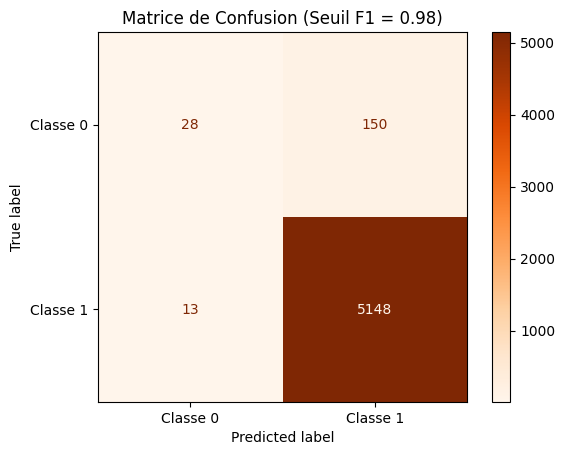

In [72]:
labels = []
raw_preds = []

with open("exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-20T16-46-45A.json") as preds_file:
        preds_dict = json.load(preds_file)

        labels = [values["label"] for video, values in preds_dict.items()]
        raw_preds = [values["pred"] for video, values in preds_dict.items()]

precisions, recalls, thresholds_pr = precision_recall_curve(labels, raw_preds)
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

# 3. Trouver le seuil qui maximise le F1-Score
best_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds_pr[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Meilleur seuil (F1-Score) : {best_threshold_f1:.4f}")
print(f"F1-Score maximum atteint : {best_f1:.4f}")

# 4. Appliquer le nouveau seuil et générer la matrice
predictions_f1 = (raw_preds >= best_threshold_f1).astype(int)
cm_f1 = confusion_matrix(labels, predictions_f1)

print("\nMatrice de confusion (Calibrée au F1-Score) :")
print(cm_f1)

# Optionnel : Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm_f1, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap=plt.cm.Oranges) # J'ai mis orange pour différencier de l'EER
plt.title(f"Matrice de Confusion (Seuil F1 = {best_threshold_f1:.2f})")
plt.show()

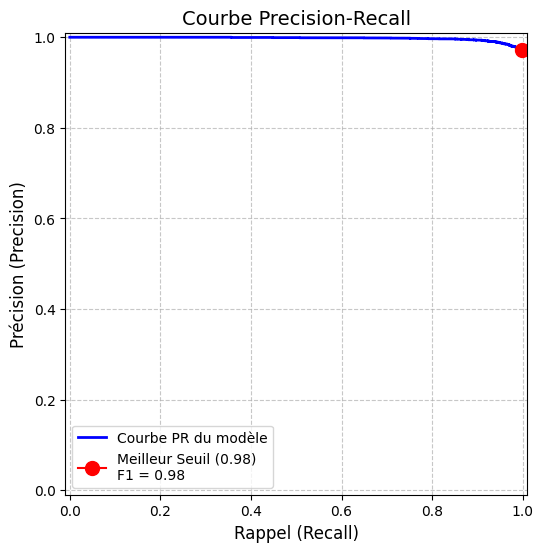

In [75]:
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]

# 2. Créer l'affichage de la courbe
fig, ax = plt.subplots(figsize=(8, 6))
disp = PrecisionRecallDisplay(precision=precisions, recall=recalls)
disp.plot(ax=ax, color='blue', linewidth=2, label='Courbe PR du modèle')

# 3. Ajouter un point rouge pour marquer le meilleur seuil F1
ax.plot(best_recall, best_precision, marker='o', color='red', markersize=10, 
        label=f'Meilleur Seuil ({best_threshold_f1:.2f})\nF1 = {best_f1:.2f}')

# 4. Améliorer la lisibilité du graphique
ax.set_title('Courbe Precision-Recall', fontsize=14)
ax.set_xlabel('Rappel (Recall)', fontsize=12)
ax.set_ylabel('Précision (Precision)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower left')

plt.show()

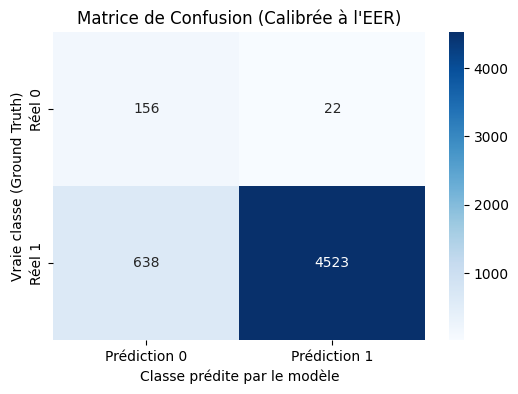

In [69]:
# Définir la taille de la figure
plt.figure(figsize=(6, 4))

# Créer une "heatmap" (carte de chaleur) avec Seaborn
# annot=True : affiche les nombres dans les cases
# fmt='d' : format entier (évite l'affichage scientifique type 1e+02)
# cmap='Blues' : palette de couleurs
sns.heatmap(cm_eer, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédiction 0', 'Prédiction 1'], 
            yticklabels=['Réel 0', 'Réel 1'])

# Ajouter les titres et les labels des axes pour que ce soit très clair
plt.title(f"Matrice de Confusion (Calibrée à l'EER)")
plt.ylabel('Vraie classe (Ground Truth)')
plt.xlabel('Classe prédite par le modèle')

# Afficher le graphique
plt.show()

In [ ]:

# 1. On identifie les vidéos en erreur pour chaque détecteur
# On crée un dictionnaire où la clé est le nom du détecteur 
# et la valeur est la liste des noms (ou IDs) des vidéos où il s'est trompé
errors_by_detector = {}

for name, df in dfs.items():
    # Masque des erreurs (prédit != réel)
    thresh = best_thresholds[name]
    pred_bin = (df['raw_pred_mean'] > 0.5).astype(int) # todo threshold
    mask_error = pred_bin != df['label']
    
    # On stocke les noms des vidéos qui sont dans ce masque
    errors_by_detector[name] = df.index[mask_error].tolist()

# 2. On transforme cela au format attendu par UpSetPlot
data_for_upset = from_contents(errors_by_detector)

# 3. Affichage du graphique
plt.figure(figsize=(15, 8))
plot(data_for_upset, show_counts=True, sort_by="cardinality")
plt.title("Error intersection by detectors")
plt.show()